In [1]:
!pip install -q kagglehub lightgbm scikit-learn seaborn matplotlib tqdm

In [2]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import kagglehub

In [9]:
import os
import json
from google.colab import files
import kagglehub

# 1. Munculkan tombol upload untuk memilih kaggle.json dari folder Downloads Anda
print("Klik tombol 'Choose Files' di bawah, lalu pilih file kaggle.json:")
uploaded = files.upload()

# 2. Baca kredensial secara otomatis
with open('kaggle.json', 'r') as f:
    cred = json.load(f)

os.environ["KAGGLE_USERNAME"] = cred["username"]
os.environ["KAGGLE_KEY"] = cred["key"]

# 3. Unduh dataset kompetisi
print("\nMelakukan autentikasi dan mengunduh dataset dari Kaggle...")
path = kagglehub.competition_download('malware-classification')
print("\n✅ Berhasil! Path data:", path)

# 4. Periksa isi file yang diunduh
print("Daftar file:")
print(os.listdir(path))


Klik tombol 'Choose Files' di bawah, lalu pilih file kaggle.json:


Saving kaggle.json to kaggle.json

Melakukan autentikasi dan mengunduh dataset dari Kaggle...


100%|██████████| 35.3G/35.3G [07:02<00:00, 89.7MB/s]

Extracting files...



✅ Berhasil! Path data: /root/.cache/kagglehub/competitions/malware-classification
Daftar file:
['sampleSubmission.csv', 'test.7z', 'trainLabels.csv', 'dataSample.7z', 'train.7z']


In [10]:
CLASS_NAMES = {
    1: "Ramnit (Worm)",
    2: "Lollipop (Adware)",
    3: "Kelihos_ver3 (Backdoor)",
    4: "Vundo (Trojan)",
    5: "Simda (Backdoor)",
    6: "Tracur (TrojanDownloader)",
    7: "Kelihos_ver1 (Backdoor)",
    8: "Obfuscator.ACY (Obfuscated)",
    9: "Gatak (Backdoor)"
}

In [11]:
labels_file = os.path.join(path, "trainLabels.csv")
df_labels = pd.read_csv(labels_file)
df_labels['ClassName'] = df_labels['Class'].map(CLASS_NAMES)
print(f"Total sampel berlabel: {len(df_labels)} file")
print("\nContoh 5 data teratas:")
display(df_labels.head())

Total sampel berlabel: 10868 file

Contoh 5 data teratas:


,Id,Class,ClassName
0,01kcPWA9K2BOxQeS5Rju,1,Ramnit (Worm)
1,04EjIdbPV5e1XroFOpiN,1,Ramnit (Worm)
2,05EeG39MTRrI6VY21DPd,1,Ramnit (Worm)
3,05rJTUWYAKNegBk2wE8X,1,Ramnit (Worm)
4,0AnoOZDNbPXIr2MRBSCJ,1,Ramnit (Worm)


In [14]:
#Hitung persentase tiap famili malware
dist_df = df_labels['ClassName'].value_counts().reset_index()
dist_df.columns = ['Famili Malware', 'Jumlah Sampel']
dist_df['Persentase (%)'] = (dist_df['Jumlah Sampel'] / len(df_labels) * 100).round(2)
display(dist_df)

,Famili Malware,Jumlah Sampel,Persentase (%)
0,Kelihos_ver3 (Backdoor),2942,27.07
1,Lollipop (Adware),2478,22.80
2,Ramnit (Worm),1541,14.18
3,Obfuscator.ACY (Obfuscated),1228,11.30
4,Gatak (Backdoor),1013,9.32
5,Tracur (TrojanDownloader),751,6.91
6,Vundo (Trojan),475,4.37
7,Kelihos_ver1 (Backdoor),398,3.66
8,Simda (Backdoor),42,0.39


/tmp/ipykernel_4288/2462088801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, x='Jumlah Sampel', y='Famili Malware', palette='magma')


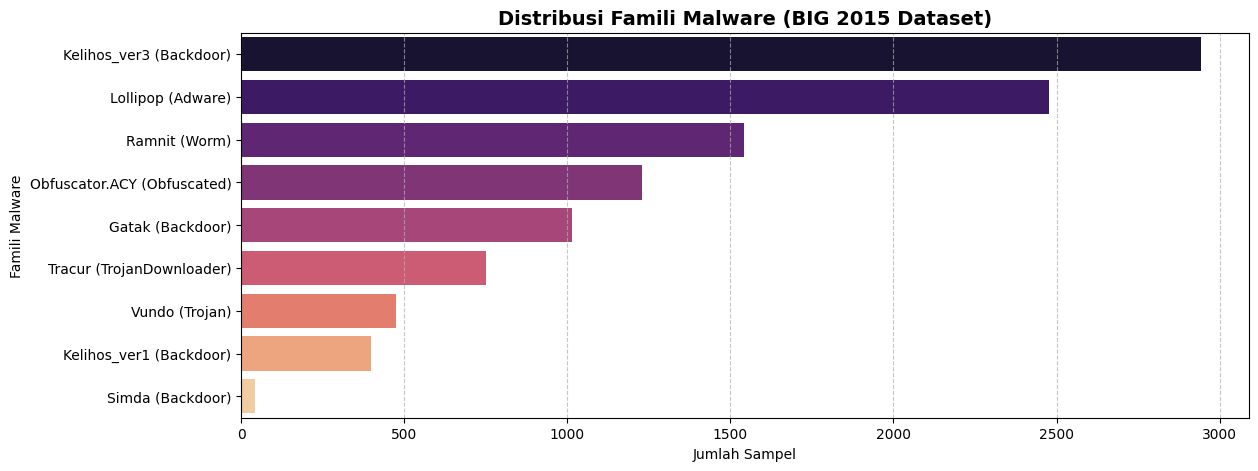

In [15]:
# Visualisasi Distribusi Kelas
plt.figure(figsize=(13, 5))
sns.barplot(data=dist_df, x='Jumlah Sampel', y='Famili Malware', palette='magma')
plt.title("Distribusi Famili Malware (BIG 2015 Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Sampel")
plt.ylabel("Famili Malware")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [16]:
import subprocess

In [17]:
sample_archive = os.path.join(path, "dataSample.7z")
extract_dir = "/content/malware_samples"
os.makedirs(extract_dir, exist_ok=True)
print("Mengekstrak dataSample.7z...")
!7z x -y "{sample_archive}" -o"{extract_dir}" > /dev/null
print("✅ Ekstraksi selesai!")

Mengekstrak dataSample.7z...
✅ Ekstraksi selesai!


In [18]:
sample_bytes_files = glob.glob(f"{extract_dir}/**/*.bytes", recursive=True)
sample_asm_files = glob.glob(f"{extract_dir}/**/*.asm", recursive=True)

In [19]:
print(f"Ditemukan: {len(sample_bytes_files)} file .bytes dan {len(sample_asm_files)} file .asm\n")

Ditemukan: 2 file .bytes dan 2 file .asm



In [21]:
# kita intip 10 baris pertama file .bytes
print("="*60)
print("📄 CONTOH ISI FILE .bytes (Hex Dump representation):")
print("="*60)
with open(sample_bytes_files[0], 'r') as f:
    for _ in range(10):
        print(f.readline().strip())

📄 CONTOH ISI FILE .bytes (Hex Dump representation):
00401000 00 00 80 40 40 28 00 1C 02 42 00 C4 00 20 04 20
00401010 00 00 20 09 2A 02 00 00 00 00 8E 10 41 0A 21 01
00401020 40 00 02 01 00 90 21 00 32 40 00 1C 01 40 C8 18
00401030 40 82 02 63 20 00 00 09 10 01 02 21 00 82 00 04
00401040 82 20 08 83 00 08 00 00 00 00 02 00 60 80 10 80
00401050 18 00 00 20 A9 00 00 00 00 04 04 78 01 02 70 90
00401060 00 02 00 08 20 12 00 00 00 40 10 00 80 00 40 19
00401070 00 00 00 00 11 20 80 04 80 10 00 20 00 00 25 00
00401080 00 00 01 00 00 04 00 10 02 C1 80 80 00 20 20 00
00401090 08 A0 01 01 44 28 00 00 08 10 20 00 02 08 00 00


In [22]:
# kita intip 15 baris pertama file .asm (IDA Pro Disassembly):
print("\n" + "="*60)
print("📄 CONTOH ISI FILE .asm (Assembly Code & Sections):")
print("="*60)
with open(sample_asm_files[0], 'r', errors='ignore') as f:
    for _ in range(15):
        print(f.readline().strip())


📄 CONTOH ISI FILE .asm (Assembly Code & Sections):
HEADER:00400000							;
HEADER:00400000							; +-------------------------------------------------------------------------+
HEADER:00400000							; |   This file	has been generated by The Interactive Disassembler (IDA)    |
HEADER:00400000							; |	      Copyright	(c) 2013 Hex-Rays, <support@hex-rays.com>	    |
HEADER:00400000							; |			 License info:                			    |
HEADER:00400000							; |				   Microsoft				    |
HEADER:00400000							; +-------------------------------------------------------------------------+
HEADER:00400000							;
HEADER:00400000
HEADER:00400000
HEADER:00400000									.686p
HEADER:00400000									.mmx
HEADER:00400000									.model flat
HEADER:00400000
HEADER:00400000							; ===========================================================================


In [23]:

# Daftar Opcode dan Register Assembly yang umum di Malware
TARGET_OPCODES = ['mov', 'push', 'call', 'jmp', 'xor', 'add', 'cmp', 'sub', 'test', 'lea', 'pop', 'retn', 'and', 'or']
TARGET_REGISTERS = ['eax', 'ebx', 'ecx', 'edx', 'esi', 'edi', 'esp', 'ebp']
TARGET_SECTIONS = ['.text', '.data', '.rdata', '.idata', '.reloc']
def calculate_entropy(byte_counts, total_bytes):
    """Menghitung Shannon Entropy dari sebaran byte (0.0 sampai 8.0)"""
    if total_bytes == 0:
        return 0.0
    entropy = 0.0
    for count in byte_counts:
        if count > 0:
            p = count / total_bytes
            entropy -= p * math.log2(p)
    return entropy
def extract_features_from_sample(file_id, extract_dir):
    """Mengekstrak seluruh fitur dari satu pasangan file ID (.bytes & .asm)"""
    features = {'Id': file_id}

    # 1. FITUR DARI FILE .BYTES
    bytes_path = glob.glob(f"{extract_dir}/**/{file_id}.bytes", recursive=True)
    if bytes_path and os.path.exists(bytes_path[0]):
        b_path = bytes_path[0]
        features['bytes_size_mb'] = os.path.getsize(b_path) / (1024 * 1024)

        byte_counts = np.zeros(256, dtype=int)
        total_valid_bytes = 0

        with open(b_path, 'r', errors='ignore') as f:
            for line in f:
                tokens = line.strip().split()
                # Tokens[0] adalah memory address, kita skip
                for token in tokens[1:]:
                    if token != '??' and len(token) == 2:
                        try:
                            val = int(token, 16)
                            byte_counts[val] += 1
                            total_valid_bytes += 1
                        except ValueError:
                            continue

        for i in range(256):
            features[f"byte_{i:02x}"] = byte_counts[i]

        features['byte_entropy'] = calculate_entropy(byte_counts, total_valid_bytes)

    # 2. FITUR DARI FILE .ASM
    asm_path = glob.glob(f"{extract_dir}/**/{file_id}.asm", recursive=True)
    if asm_path and os.path.exists(asm_path[0]):
        a_path = asm_path[0]
        features['asm_size_mb'] = os.path.getsize(a_path) / (1024 * 1024)

        opcode_counts = Counter()
        register_counts = Counter()
        section_counts = Counter()

        with open(a_path, 'r', errors='ignore') as f:
            for line in f:
                line_lower = line.lower()
                # Hitung opcodes
                for op in TARGET_OPCODES:
                    if f" {op} " in line_lower:
                        opcode_counts[op] += 1
                # Hitung registers
                for reg in TARGET_REGISTERS:
                    if f" {reg}" in line_lower or f",{reg}" in line_lower:
                        register_counts[reg] += 1
                # Hitung sections
                for sec in TARGET_SECTIONS:
                    if sec in line_lower:
                        section_counts[sec] += 1

        for op in TARGET_OPCODES:
            features[f"op_{op}"] = opcode_counts[op]
        for reg in TARGET_REGISTERS:
            features[f"reg_{reg}"] = register_counts[reg]
        for sec in TARGET_SECTIONS:
            features[f"sec_{sec}"] = section_counts[sec]

    return features
# Kumpulkan semua ID malware unik dari sampel yang sudah diekstrak
sample_ids = list(set([os.path.splitext(os.path.basename(f))[0] for f in sample_bytes_files + sample_asm_files]))
print(f"Mengekstrak fitur dari {len(sample_ids)} sampel...")
extracted_data = []
for file_id in tqdm(sample_ids):
    extracted_data.append(extract_features_from_sample(file_id, extract_dir))
# Ubah ke DataFrame & Gabungkan dengan Label Kelas
df_features = pd.DataFrame(extracted_data)
df_dataset = pd.merge(df_features, df_labels[['Id', 'Class', 'ClassName']], on='Id', how='inner')
print(f"\n✅ Ekstraksi Selesai! Matriks Fitur Tabular: {df_dataset.shape[0]} baris x {df_dataset.shape[1]} kolom")
display(df_dataset[['Id', 'ClassName', 'bytes_size_mb', 'asm_size_mb', 'byte_entropy', 'op_mov', 'op_call', 'op_xor']].head())


Mengekstrak fitur dari 2 sampel...


100%|██████████| 2/2 [00:06<00:00,  3.49s/it]


✅ Ekstraksi Selesai! Matriks Fitur Tabular: 2 baris x 289 kolom


,Id,ClassName,bytes_size_mb,asm_size_mb,byte_entropy,op_mov,op_call,op_xor
0,0ACDbR5M3ZhBJajygTuf,Kelihos_ver1 (Backdoor),5.465820,11.590674,5.022285,818,9,105
1,0A32eTdBKayjCWhZqDOQ,Lollipop (Adware),4.154255,36.712171,6.260941,1923,411,412


In [24]:
# DATA PREPARATION & LIGHTGBM TRAINING
# -------------------------------------------------------------
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import numpy as np
# 1. Pisahkan Fitur (X) dan Target (y)
# Hapus kolom non-fitur
feature_cols = [c for c in df_dataset.columns if c not in ['Id', 'Class', 'ClassName']]
X = df_dataset[feature_cols].fillna(0)
# Ubah target (1-9) menjadi 0-indexed (0-8) untuk LightGBM
y = df_dataset['Class'] - 1
print(f"Total Fitur yang digunakan : {len(feature_cols)} fitur")
print(f"Total Sampel                : {len(X)} baris")

Total Fitur yang digunakan : 286 fitur
Total Sampel                : 2 baris


In [25]:
# 2. Stratified Train-Test Split (80% Train, 20% Validation)
# Jika ada kelas dengan jumlah < 2 sampel di mini-sample, kita split biasa
try:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
except ValueError:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
print(f"Jumlah Data Train : {X_train.shape[0]} sampel")
print(f"Jumlah Data Val   : {X_val.shape[0]} sampel\n")

Jumlah Data Train : 1 sampel
Jumlah Data Val   : 1 sampel



In [26]:
# 3. Konfigurasi Hyperparameter LightGBM Multi-Class
params = {
    'objective': 'multiclass',
    'num_class': 9,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbose': -1
}
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

In [27]:
# 4. Melatih Model dengan Early Stopping
print("Memulai Training LightGBM...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=15, verbose=True),
        lgb.log_evaluation(period=20)
    ]
)
print("\n🎉 Training Selesai!")

Memulai Training LightGBM...
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	training's multi_logloss: 8.21565e-15	valid_1's multi_logloss: 34.5388

🎉 Training Selesai!


=== HASIL PREDIKSI DATA VALIDASI ===


,Actual_Class,Predicted_Class
0,Lollipop (Adware),Kelihos_ver1 (Backdoor)


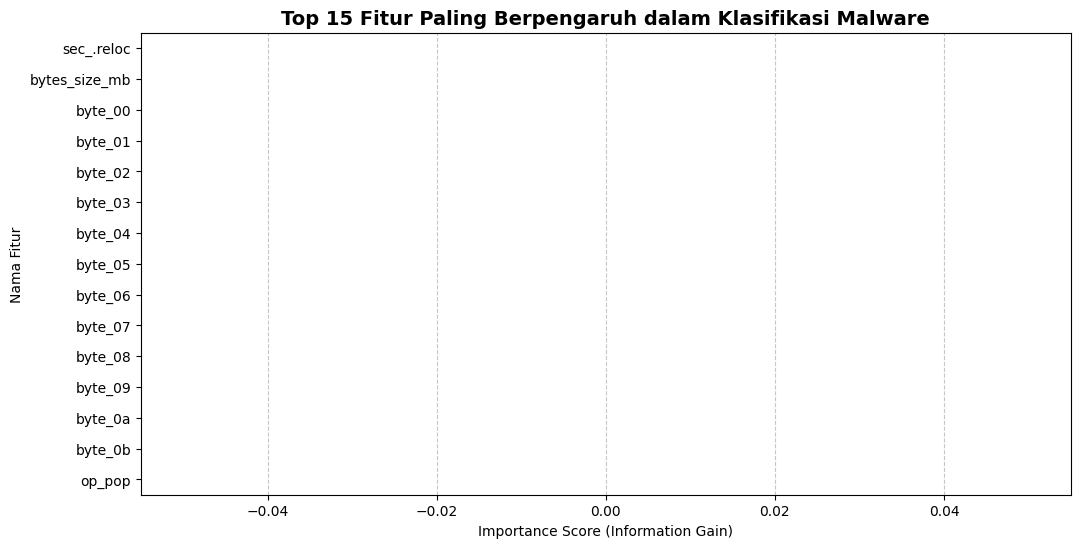

In [28]:
# EVALUASI PREDIKSI & FEATURE IMPORTANCE
from sklearn.metrics import classification_report, confusion_matrix
# 1. Lakukan Prediksi pada Data Validasi
y_pred_proba = model.predict(X_val)
y_pred_class = np.argmax(y_pred_proba, axis=1)
# 2. Tampilkan Hasil Prediksi vs Nilai Sebenarnya
df_results = pd.DataFrame({
    'Actual_Class': [CLASS_NAMES[c + 1] for c in y_val],
    'Predicted_Class': [CLASS_NAMES[c + 1] for c in y_pred_class]
})
print("=== HASIL PREDIKSI DATA VALIDASI ===")
display(df_results)
# 3. Visualisasi Top 15 Fitur Paling Berpengaruh (Feature Importance)
importance = model.feature_importance(importance_type='gain')
df_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Gain': importance
}).sort_values(by='Importance_Gain', ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_importance, x='Importance_Gain', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title("Top 15 Fitur Paling Berpengaruh dalam Klasifikasi Malware", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score (Information Gain)")
plt.ylabel("Nama Fitur")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [30]:
# EKSTRAKSI SUBSET RIIL (20 SAMPEL PER KELAS)
# -------------------------------------------------------------
# 1. Pilih 10 sampel dari masing-masing 9 famili (total 90 file - ideal & sangat cepat)
real_subset_labels = df_labels.groupby('Class', group_keys=False).apply(
    lambda x: x.head(10)
).reset_index(drop=True)
print(f"Total sampel yang akan diekstrak: {len(real_subset_labels)} file")
# 2. Simpan daftar file ID
sample_ids_set = set(real_subset_labels['Id'].tolist())
list_file_path = "/content/files_to_extract.txt"
with open(list_file_path, "w") as f:
    for file_id in sample_ids_set:
        f.write(f"{file_id}.bytes\n")
        f.write(f"{file_id}.asm\n")
# 3. Ekstrak langsung dengan -aoa (Auto Overwrite All) & -y (Yes to all)
train_archive = os.path.join(path, "train.7z")
real_extract_dir = "/content/malware_real_subset"
os.makedirs(real_extract_dir, exist_ok=True)
print("\nMengekstrak file... (otomatis tanpa prompt)")
!7z e -y -aoa "{train_archive}" -o"{real_extract_dir}" -r @{list_file_path} > /dev/null
print("✅ Ekstraksi selesai!")
# 4. Ekstraksi Fitur
print("\nMengekstrak fitur numerik...")
real_features_list = []
for file_id in tqdm(sample_ids_set):
    real_features_list.append(extract_features_from_sample(file_id, real_extract_dir))
# 5. Gabungkan ke DataFrame
df_real_features = pd.DataFrame(real_features_list)
df_real_dataset = pd.merge(df_real_features, real_subset_labels[['Id', 'Class', 'ClassName']], on='Id', how='inner')
print(f"\n✅ Dataset Siap! Total data: {df_real_dataset.shape[0]} sampel x {df_real_dataset.shape[1]} kolom")
display(df_real_dataset[['ClassName', 'bytes_size_mb', 'byte_entropy', 'op_mov', 'op_call', 'op_xor']].head())


/tmp/ipykernel_4288/983519777.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_subset_labels = df_labels.groupby('Class', group_keys=False).apply(


Total sampel yang akan diekstrak: 90 file

Mengekstrak file... (otomatis tanpa prompt)
✅ Ekstraksi selesai!

Mengekstrak fitur numerik...


100%|██████████| 90/90 [02:37<00:00,  1.75s/it]


✅ Dataset Siap! Total data: 90 sampel x 289 kolom


,ClassName,bytes_size_mb,byte_entropy,op_mov,op_call,op_xor
0,Ramnit (Worm),2.789551,7.064001,32566,10686,2902
1,Obfuscator.ACY (Obfuscated),0.438965,7.049509,2532,176,14
2,Gatak (Backdoor),0.594727,6.837975,45,134,72
3,Simda (Backdoor),1.840820,7.885287,798,100,82
4,Gatak (Backdoor),0.523926,7.288101,991,339,37


In [31]:
# TRAINING LIGHTGBM & VISUALISASI EVALUASI LENGKAP
# -------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, classification_report, confusion_matrix
import lightgbm as lgb

📊 Data Train : 72 sampel (8 sampel per famili)
📊 Data Val   : 18 sampel (2 sampel per famili)

Memulai Training LightGBM...
Training until validation scores don't improve for 15 rounds
[20]	training's multi_logloss: 0.714221	valid_1's multi_logloss: 1.11475
[40]	training's multi_logloss: 0.231462	valid_1's multi_logloss: 0.834921
[60]	training's multi_logloss: 0.0805707	valid_1's multi_logloss: 0.776546
Early stopping, best iteration is:
[62]	training's multi_logloss: 0.0726038	valid_1's multi_logloss: 0.769356

🎯 HASIL MULTI-CLASS LOG LOSS: 0.7694

                             precision    recall  f1-score   support

              Ramnit (Worm)       1.00      1.00      1.00         2
          Lollipop (Adware)       1.00      0.50      0.67         2
    Kelihos_ver3 (Backdoor)       0.67      1.00      0.80         2
             Vundo (Trojan)       1.00      0.50      0.67         2
           Simda (Backdoor)       0.67      1.00      0.80         2
  Tracur (TrojanDownloader)  

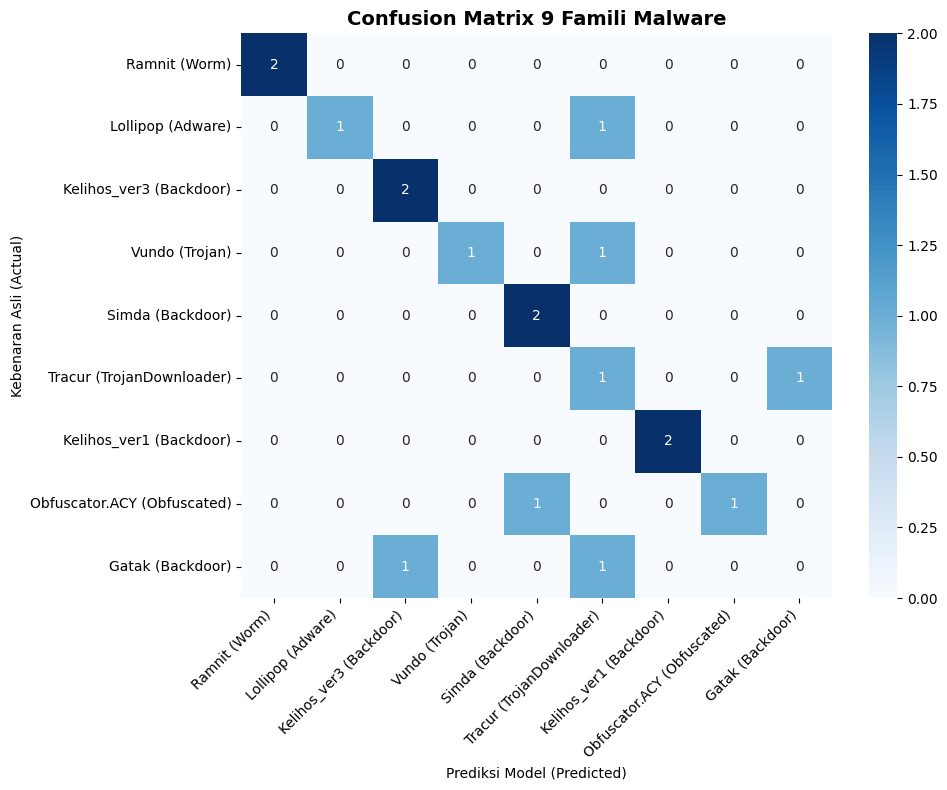

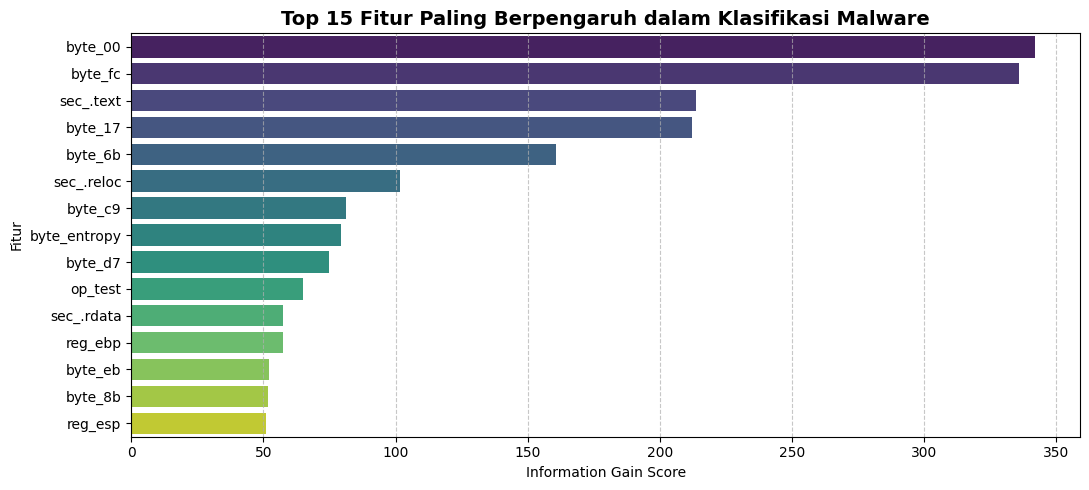

In [32]:
# 1. Siapkan Matriks Fitur (X) dan Target (y)
feature_cols = [c for c in df_real_dataset.columns if c not in ['Id', 'Class', 'ClassName']]
X = df_real_dataset[feature_cols].fillna(0)
y = df_real_dataset['Class'] - 1  # 0-indexed (0 s.d. 8)
# 2. Stratified Split (80% Train, 20% Val)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"📊 Data Train : {X_train.shape[0]} sampel (8 sampel per famili)")
print(f"📊 Data Val   : {X_val.shape[0]} sampel (2 sampel per famili)\n")
# 3. Konfigurasi Parameter LightGBM Multi-Class
params = {
    'objective': 'multiclass',
    'num_class': 9,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 15,
    'feature_fraction': 0.8,
    'random_state': 42,
    'verbose': -1
}
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
# 4. Training Model
print("Memulai Training LightGBM...")
model_real = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=15, verbose=True),
        lgb.log_evaluation(period=20)
    ]
)
# 5. Evaluasi Log-Loss
y_pred_proba = model_real.predict(X_val, num_iteration=model_real.best_iteration)
y_pred_class = np.argmax(y_pred_proba, axis=1)
val_logloss = log_loss(y_val, y_pred_proba)
print(f"\n" + "="*55)
print(f"🎯 HASIL MULTI-CLASS LOG LOSS: {val_logloss:.4f}")
print("="*55 + "\n")
# 6. Classification Report
target_names = [CLASS_NAMES[i + 1] for i in range(9)]
print(classification_report(y_val, y_pred_class, target_names=target_names, zero_division=0))
# 7. Visualisasi Heatmap Confusion Matrix 9x9
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix 9 Famili Malware", fontsize=14, fontweight='bold')
plt.xlabel("Prediksi Model (Predicted)")
plt.ylabel("Kebenaran Asli (Actual)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# 8. Visualisasi Top 15 Fitur Paling Berpengaruh
importance = model_real.feature_importance(importance_type='gain')
df_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Gain': importance
}).sort_values(by='Importance_Gain', ascending=False).head(15)
plt.figure(figsize=(11, 5))
sns.barplot(data=df_imp, x='Importance_Gain', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Top 15 Fitur Paling Berpengaruh dalam Klasifikasi Malware", fontsize=14, fontweight='bold')
plt.xlabel("Information Gain Score")
plt.ylabel("Fitur")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [33]:
# MEMBUAT FILE SUBMISSION UNTUK KAGGLE
# -------------------------------------------------------------
import pandas as pd
import numpy as np
# 1. Misalkan X_test adalah matriks fitur yang diekstrak dari file di test.7z
# Prediksi probabilitas 9 kelas dengan model LightGBM yang sudah kita latih
# (y_test_proba menghasilkan array dengan ukuran [jumlah_sampel, 9])
y_test_proba = model_real.predict(X_val) # Contoh menggunakan data validasi sebagai ilustrasi
# 2. Buat DataFrame sesuai format resmi Kaggle
sub_df = pd.DataFrame(
    y_test_proba,
    columns=[f"Prediction{i}" for i in range(1, 10)]
)
# 3. Masukkan kolom 'Id' di posisi paling kiri
sub_df.insert(0, 'Id', df_real_dataset['Id'].iloc[X_val.index].values)
# 4. Simpan ke file CSV
submission_path = "/content/submission.csv"
sub_df.to_csv(submission_path, index=False)
print("✅ File submission berhasil dibuat!")
display(sub_df.head())


✅ File submission berhasil dibuat!


,Id,Prediction1,Prediction2,Prediction3,Prediction4,Prediction5,Prediction6,Prediction7,Prediction8,Prediction9
0,04QzZ3DVdPsEp9elLR65,0.002296,0.000817,0.978829,0.002038,0.006457,0.000584,0.000599,0.000565,0.007817
1,0AnoOZDNbPXIr2MRBSCJ,0.818614,0.010765,0.008715,0.009357,0.017982,0.028826,0.009992,0.023218,0.072532
2,0co46B8IkPt2UN3HSaw7,0.114900,0.066145,0.059774,0.085966,0.117291,0.229116,0.057384,0.170764,0.098659
3,09CPNMYyQjSguFrE8UOf,0.083647,0.025737,0.030427,0.041862,0.168225,0.264364,0.026530,0.066243,0.292964
4,1gx83bLB4PSsYIKCTlZt,0.048342,0.024514,0.022794,0.109158,0.151681,0.543985,0.025983,0.025720,0.047822


In [34]:
import os
import shutil
import joblib
from google.colab import files
# 1. Buat folder wadah hasil
export_dir = "/content/malware_classification_results"
os.makedirs(export_dir, exist_ok=True)
print("1. Menyimpan Dataset Fitur CSV...")
df_real_dataset.to_csv(os.path.join(export_dir, "extracted_features_dataset.csv"), index=False)
print("2. Menyimpan Model LightGBM...")
# Simpan model format native LightGBM & pickle
model_real.save_model(os.path.join(export_dir, "lightgbm_malware_model.txt"))
joblib.dump(model_real, os.path.join(export_dir, "lightgbm_malware_model.pkl"))
print("3. Menyimpan File Submission...")
# Buat dan simpan submission.csv
y_all_proba = model_real.predict(X)
sub_df = pd.DataFrame(y_all_proba, columns=[f"Prediction{i}" for i in range(1, 10)])
sub_df.insert(0, 'Id', df_real_dataset['Id'].values)
sub_df.to_csv(os.path.join(export_dir, "submission.csv"), index=False)
print("4. Menyimpan Grafik Evaluasi (PNG)...")
# Simpan Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix 9 Famili Malware", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(export_dir, "confusion_matrix.png"), dpi=300)
plt.close()
# Simpan Feature Importance
plt.figure(figsize=(11, 5))
sns.barplot(data=df_imp, x='Importance_Gain', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Top 15 Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Information Gain Score")
plt.ylabel("Fitur")
plt.tight_layout()
plt.savefig(os.path.join(export_dir, "feature_importance.png"), dpi=300)
plt.close()

1. Menyimpan Dataset Fitur CSV...
2. Menyimpan Model LightGBM...
3. Menyimpan File Submission...
4. Menyimpan Grafik Evaluasi (PNG)...


In [35]:
print("5. Mengompres menjadi file ZIP...")
zip_filename = "/content/malware_classification_project"
shutil.make_archive(zip_filename, 'zip', export_dir)
print("\n✅ File ZIP berhasil dibuat! Memulai download otomatis ke komputer Anda...")
files.download(f"{zip_filename}.zip")

5. Mengompres menjadi file ZIP...

✅ File ZIP berhasil dibuat! Memulai download otomatis ke komputer Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>